In [53]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


##1. Loading and Preprocessing MNIST Handwritten Digit Dataset:

In [54]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0
print(x_train.shape)

x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

(60000, 28, 28)


In [55]:
print(y_test)

[[0. 0. 0. ... 1. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


##2. Build the Model:

##1. Sequential API:

In [56]:
# Model parameters
import tensorflow as tf
from tensorflow import keras
num_classes = 10
input_shape = (28*28, )
model = keras.Sequential(
[
keras.layers.Input(shape=input_shape),
keras.layers.Flatten(), # Flatten the 28x28 image to a 784-dimensional vector
keras.layers.Dense(64, activation="sigmoid"),
keras.layers.Dense(128, activation="sigmoid"),
keras.layers.Dense(256, activation="sigmoid"),
keras.layers.Dense(num_classes, activation="softmax"),
]
)

##Syntax Model Summary

In [57]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

##Compiling the model

In [58]:
model.compile(
optimizer="sgd", # Stochastic Gradient Descent
loss="categorical_crossentropy", # Loss function for multi-class classification
metrics=["accuracy"] # Track accuracy during training
)

In [59]:
batch_size = 128
epochs = 100

callbacks = [
keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
keras.callbacks.EarlyStopping(monitor="val_loss", patience=4 ),
]

history = model.fit(
x_train,
y_train,
batch_size=batch_size,
epochs=epochs,
validation_split=0.15,
callbacks=callbacks,
)

Epoch 1/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1096 - loss: 2.3084 - val_accuracy: 0.1063 - val_loss: 2.3022
Epoch 2/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1143 - loss: 2.3000 - val_accuracy: 0.1553 - val_loss: 2.2995
Epoch 3/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.1167 - loss: 2.2986 - val_accuracy: 0.1063 - val_loss: 2.2989
Epoch 4/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1192 - loss: 2.2969 - val_accuracy: 0.1359 - val_loss: 2.2979
Epoch 5/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.1271 - loss: 2.2955 - val_accuracy: 0.1063 - val_loss: 2.2961
Epoch 6/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1222 - loss: 2.2936 - val_accuracy: 0.0963 - val_loss: 2.2947
Epoch 7/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1336 - loss: 2.2916 - val_accuracy: 0.1063 - val_loss: 2.2920
Epoch 8/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1390 - loss: 2.2892 - val_acc

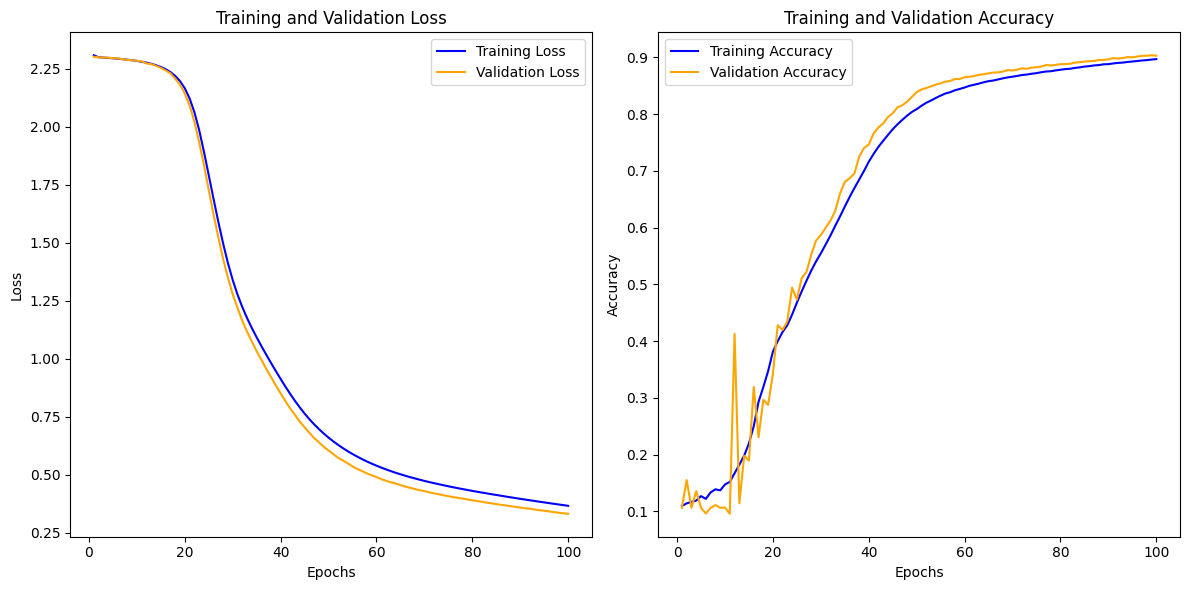

In [60]:
import matplotlib.pyplot as plt

train_loss = history.history['loss']
val_loss = history.history['val_loss']

train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Training Loss', color='blue')
plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy', color='blue')
plt.plot(range(1, len(val_acc) + 1), val_acc, label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [61]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

313/313 - 1s - 3ms/step - accuracy: 0.8993 - loss: 0.3564
Test accuracy: 0.8993


##Task 1: Data Preparation
Loading the Data
• Download the provided folder that contains the Devnagari digits dataset.
• Use the Python Imaging Library (PIL) to load and read the image files from the dataset.
• Convert the images into Numpy arrays and normalize them to a range of 0-1.
• use train folder for training and test for testing.
• Extract the corresponding labels for each image.

In [80]:
import os
import numpy as np
from PIL import Image
from tensorflow.keras.utils import to_categorical

IMG_SIZE = 28

def load_data(data_dir):
    images = []
    labels = []

    for folder in os.listdir(data_dir):
        folder_path = os.path.join(data_dir, folder)

        #  Skip the Test folder when loading training data
        if folder == "Test":
            continue

        if os.path.isdir(folder_path):
            # Extract label (digit_0 → 0)
            label = int(folder.split("_")[-1])

            for file in os.listdir(folder_path):
                img_path = os.path.join(folder_path, file)

                try:
                    img = Image.open(img_path).convert('L')
                    img = img.resize((IMG_SIZE, IMG_SIZE))

                    img_array = np.array(img)

                    images.append(img_array)
                    labels.append(label)

                except:
                    print("Error loading:", img_path)

    return np.array(images), np.array(labels)


def load_test_data(test_dir):
    images = []
    labels = []

    for folder in os.listdir(test_dir):
        folder_path = os.path.join(test_dir, folder)

        if os.path.isdir(folder_path):
            label = int(folder.split("_")[-1])

            for file in os.listdir(folder_path):
                img_path = os.path.join(folder_path, file)

                try:
                    img = Image.open(img_path).convert('L')
                    img = img.resize((IMG_SIZE, IMG_SIZE))

                    img_array = np.array(img)

                    images.append(img_array)
                    labels.append(label)

                except:
                    print("Error loading:", img_path)

    return np.array(images), np.array(labels)


# ✅ Paths
train_path = "/content/drive/MyDrive/AI and Machine Learning/Week4/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Test"
test_path = "/content/drive/MyDrive/AI and Machine Learning/Week4/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Test"

# Load data
x_train, y_train = load_data(train_path)
x_test, y_test = load_test_data(test_path)

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encoding
num_classes = 10

y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

print("Train:", x_train.shape, y_train.shape)
print("Test:", x_test.shape, y_test.shape)

Train: (554, 28, 28, 1) (554, 10)
Test: (554, 28, 28, 1) (554, 10)


##Task 2: Build the FCN Model
Model Architecture
• Create a Sequential model using Keras.
• Add 3 hidden layers with the following number of neurons:
– 1st hidden layer: 64 neurons
– 2nd hidden layer: 128 neurons
– 3rd hidden layer: 256 neurons
• Use sigmoid activation functions for all hidden layers.
• Add an output layer with 10 units with softmax (since Devnagari digits have 10 classes) and a
softmax activation function.

In [81]:
from tensorflow import keras
from tensorflow.keras import layers

# Create model
model = keras.Sequential([

    # Flatten input (28x28 → 784)
    layers.Flatten(input_shape=(28, 28, 1)),

    # Hidden Layer 1
    layers.Dense(64, activation='sigmoid'),

    # Hidden Layer 2
    layers.Dense(128, activation='sigmoid'),

    # Hidden Layer 3
    layers.Dense(256, activation='sigmoid'),

    # Output Layer (10 classes)
    layers.Dense(10, activation='softmax')
])

# Show model summary
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_12 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

##Task 3: Compile the Model
Model Compilation
• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy).

In [82]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

##Task 4: Train the Model
Model Training
• Use the model.fit() function to train the model. Set the batch size to 128 and the number of
epochs to 20.
• Use validation split (validation split=0.2) to monitor the model’s performance on validation
data.
• Optionally, use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model
and avoiding overfitting.

In [83]:
from tensorflow import keras

batch_size = 128
epochs = 20

# Callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="best_model.keras",
        monitor="val_loss",
        save_best_only=True
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )
]

# Train the model
history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.2393 - loss: 2.0949 - val_accuracy: 0.0000e+00 - val_loss: 1.6885
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5734 - loss: 1.0704 - val_accuracy: 0.0000e+00 - val_loss: 1.0780
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5734 - loss: 0.7540 - val_accuracy: 0.0000e+00 - val_loss: 0.7486
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6230 - loss: 0.6822 - val_accuracy: 0.0000e+00 - val_loss: 0.7982
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5734 - loss: 0.6388 - val_accuracy: 0.0000e+00 - val_loss: 0.8663
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5734 - loss: 0.6040 - val_accuracy: 0.0901 - val_loss: 0.7369
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8510 - loss: 0.5522 - val_accuracy: 0.9730 - val_loss: 0.5669
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9955 - loss: 0.4859 - val_accuracy: 0.936

##Task 5: Evaluate the Model
Model Evaluation
• After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.

In [84]:
# Evaluate on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0111 
Test Loss: 0.011063781566917896
Test Accuracy: 1.0


##Task 6: Save and Load the Model
Model Saving and Loading
• Save the trained model to an .h5 file using model.save().
• Load the saved model and re-evaluate its performance on the test set.

In [85]:
model.save("devanagari_model.h5")

In [86]:
from tensorflow.keras.models import load_model

loaded_model = load_model("devanagari_model.h5")

In [87]:
test_loss, test_accuracy = loaded_model.evaluate(x_test, y_test)

print("Loaded Model Test Loss:", test_loss)
print("Loaded Model Test Accuracy:", test_accuracy)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0111  
Loaded Model Test Loss: 0.011063781566917896
Loaded Model Test Accuracy: 1.0


##Task 7: Predictions
Making Predictions
• Use model.predict() to make predictions on test images.
• Convert the model’s predicted probabilities to digit labels using np.argmax().

##Predict on Test Data

In [88]:
import numpy as np

# Predict probabilities
predictions = model.predict(x_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


##Convert to Digit Labels

In [89]:
predicted_labels = np.argmax(predictions, axis=1)

##Get Actual Labels

In [90]:
true_labels = np.argmax(y_test, axis=1)

##Compare Predictions vs Actual

In [91]:
for i in range(10):
    print("Predicted:", predicted_labels[i],
          "Actual:", true_labels[i])

Predicted: 1 Actual: 1
Predicted: 1 Actual: 1
Predicted: 1 Actual: 1
Predicted: 1 Actual: 1
Predicted: 1 Actual: 1
Predicted: 1 Actual: 1
Predicted: 1 Actual: 1
Predicted: 1 Actual: 1
Predicted: 1 Actual: 1
Predicted: 1 Actual: 1


##Expected Deliverables
• Code Implementation: Complete code for building, training, evaluating, saving, and loading
the model.
• Visualization: Graphs showing the training and validation loss and accuracy.
• Test Accuracy: Display the final test accuracy.
• Saved Model: Submit the saved .h5 model file.

##Required Flow

Load Data → Preprocess → Build Model → Compile → Train → Evaluate → Save → Load → Predict

##Visualization

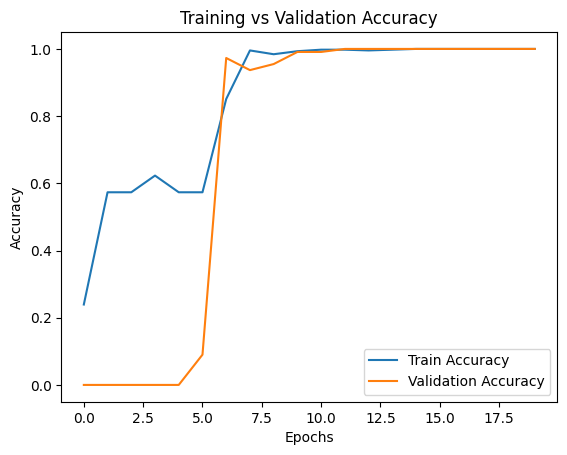

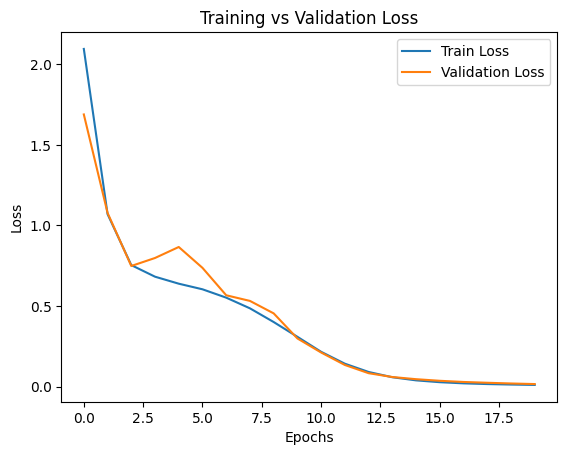

In [92]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

# Loss plot
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

##Test Accuracy

In [93]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Final Test Accuracy:", test_accuracy)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0111
Final Test Accuracy: 1.0


##Saved Model File

In [94]:
model.save("devanagari_model.h5")